# Notebook 2 — Treinamento e Detecção de Drift

## Aula 1: Fundamentos do Data Drift em ML

### Objetivos
- Treinar um classificador nos dados de referência (períodos 1–2)
- Avaliar a degradação do modelo nos dados com drift (períodos 3–5)
- Aplicar o **teste Kolmogorov-Smirnov** para detectar drift estatisticamente
- Entender a relação entre drift detectado e queda de acurácia

### Teoria-Chave (Documento 04)

> O **teste Kolmogorov-Smirnov (KS)** compara duas amostras e retorna um p-value
> indicando a probabilidade das distribuições serem iguais. Um p-value baixo
> (< 0.05) sugere **deriva de dados**.
>
> — Seção *Hands On — Snippet 1*

> Monitorar as **métricas de desempenho do modelo ao longo do tempo** é a
> primeira linha de defesa contra o data drift.
>
> — Seção *Saiba Mais — Monitoramento e Detecção de Drift*

In [1]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import DataPreprocessor
from src.model import AdaptiveClassifier, DriftDetector
from src.training import train_model, cross_validate
from src.evaluation import (
    calculate_metrics,
    calculate_metrics_per_period,
    plot_accuracy_over_time,
    plot_distribution_comparison,
)
from src.utils import save_model, save_metrics, ensure_dirs

sns.set_theme(style="whitegrid")
%matplotlib inline

ensure_dirs()

## 1. Carga e Preparação dos Dados

Dividimos por período: períodos 1–2 como **treino** (referência) e
períodos 3–5 como **teste** (dados potencialmente com drift).

In [2]:
# Carrega dataset
preprocessor = DataPreprocessor(random_state=42)
data_path = Path.cwd().parent / "data" / "raw" / "dataset.csv"

if data_path.exists():
    df = preprocessor.load_data(data_path)
else:
    df = preprocessor.generate_synthetic_data(n_samples=10_000)
    preprocessor.save_data(df, data_path)

# Divisão temporal
df_train, df_test = preprocessor.split_by_period(
    df, train_periods=[1, 2], test_periods=[3, 4, 5]
)

print(f"Treino: {len(df_train)} amostras (períodos 1-2)")
print(f"Teste:  {len(df_test)} amostras  (períodos 3-5)")

# Preparação de features (padronização)
X_train, y_train = preprocessor.prepare_features(df_train, fit=True)
X_test, y_test = preprocessor.prepare_features(df_test, fit=False)

Treino: 4000 amostras (períodos 1-2)
Teste:  6000 amostras  (períodos 3-5)


## 2. Validação Cruzada nos Dados de Referência

In [3]:
# Validação cruzada 5-fold nos dados de treino
cv_results = cross_validate(X_train, y_train, n_folds=5)

print("Resultados da Validação Cruzada (5-Fold):")
print(f"  Acurácia treino: {np.mean(cv_results['train_scores']):.4f} ± {np.std(cv_results['train_scores']):.4f}")
print(f"  Acurácia valid.: {np.mean(cv_results['val_scores']):.4f} ± {np.std(cv_results['val_scores']):.4f}")

Resultados da Validação Cruzada (5-Fold):
  Acurácia treino: 0.9079 ± 0.0027
  Acurácia valid.: 0.9110 ± 0.0033


## 3. Treinamento do Modelo Base

Treinamos o `AdaptiveClassifier` (SGDClassifier) nos dados de referência
(períodos 1–2) e salvamos para uso posterior.

In [4]:
# Treina modelo nos dados de referência
model = train_model(X_train, y_train, random_state=42)

# Acurácia nos dados de treino (referência)
train_score = model.score(X_train, y_train)
print(f"Acurácia no treino: {train_score:.4f}")

# Salva modelo
model_path = Path.cwd().parent / "outputs" / "models" / "model_base.joblib"
save_model(model, model_path)
print(f"Modelo salvo em {model_path}")

Acurácia no treino: 0.9062
Modelo salvo em c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\01_fundamentos_do_data_drift_em_ml\outputs\models\model_base.joblib


## 4. Avaliação da Degradação por Período

Conforme a **Figura 1** do material da aula (*"Desempenho de um modelo de ML
decaindo ao longo do tempo"*), esperamos que a acurácia caia à medida que o
drift aumenta nos períodos 3, 4 e 5.

In [5]:
# Avalia modelo em TODOS os períodos para ver degradação
X_all, y_all = preprocessor.prepare_features(df, fit=False)
y_pred_all = model.predict(X_all)
periods_all = df["periodo"].values

metrics_by_period = calculate_metrics_per_period(y_all, y_pred_all, periods_all)

print("Métricas por período:")
for p, m in sorted(metrics_by_period.items()):
    drift_label = "(referência)" if p <= 2 else "(drift)"
    print(f"  Período {p} {drift_label}: Acc={m['accuracy']:.4f}  F1={m['f1']:.4f}")

Métricas por período:
  Período 1 (referência): Acc=0.9075  F1=0.9074
  Período 2 (referência): Acc=0.9050  F1=0.9037
  Período 3 (drift): Acc=0.8950  F1=0.9175
  Período 4 (drift): Acc=0.9110  F1=0.9410
  Período 5 (drift): Acc=0.8860  F1=0.9322


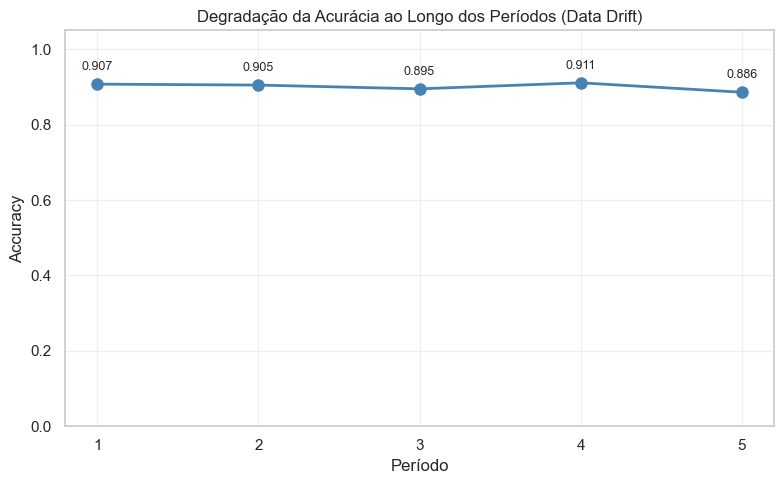

In [6]:
# Gráfico de degradação — reproduz a análise da Figura 1 do doc 04
fig = plot_accuracy_over_time(
    metrics_by_period,
    metric_name="accuracy",
    title="Degradação da Acurácia ao Longo dos Períodos (Data Drift)",
    save_path=Path.cwd().parent / "outputs" / "figures" / "degradacao_acuracia.png",
)
plt.show()

## 5. Detecção Estatística de Drift (Teste KS)

Implementa o **Snippet 1** do Hands On: comparação de distribuições com
`scipy.stats.ks_2samp`.  O teste KS retorna:
- **Estatística KS**: $D = \sup_x |F_{\text{ref}}(x) - F_{\text{prod}}(x)|$
- **p-value**: se $p < 0.05$, rejeitamos $H_0$ (distribuições iguais)

In [7]:
# Detecção de drift: compara períodos de referência vs cada período com drift
detector = DriftDetector(alpha=0.05)
feature_names = DataPreprocessor.FEATURE_NAMES

# Dados de referência (períodos 1-2)
X_ref = X_train

print("Detecção de Drift por Período (Teste KS, α=0.05)\n")
print(f"{'Período':<10} {'Features c/ Drift':<20} {'Nomes'}")
print("-" * 70)

for period in [3, 4, 5]:
    df_p = df[df["periodo"] == period]
    X_p, _ = preprocessor.prepare_features(df_p, fit=False)
    
    results = detector.detect_multivariate(X_ref, X_p, feature_names)
    summary = detector.summary(results)
    
    print(f"{period:<10} {summary['features_with_drift']:<20} {summary['drifted_features']}")

Detecção de Drift por Período (Teste KS, α=0.05)

Período    Features c/ Drift    Nomes
----------------------------------------------------------------------
3          5                    ['idade', 'renda_mensal', 'tempo_no_site_min', 'paginas_visitadas', 'itens_carrinho']
4          5                    ['idade', 'renda_mensal', 'tempo_no_site_min', 'paginas_visitadas', 'itens_carrinho']
5          5                    ['idade', 'renda_mensal', 'tempo_no_site_min', 'paginas_visitadas', 'itens_carrinho']


In [8]:
# Detalhamento: p-values para Período 5 (maior drift)
df_p5 = df[df["periodo"] == 5]
X_p5, _ = preprocessor.prepare_features(df_p5, fit=False)
results_p5 = detector.detect_multivariate(X_ref, X_p5, feature_names)

print("Resultados KS detalhados — Período 5 vs Referência:\n")
print(f"{'Feature':<30} {'Estatística KS':<18} {'p-value':<15} {'Drift?'}")
print("-" * 75)
for r in results_p5:
    flag = "⚠️ SIM" if r.drift_detected else "✅ NÃO"
    print(f"{r.feature_name:<30} {r.statistic:<18.4f} {r.p_value:<15.6f} {flag}")

Resultados KS detalhados — Período 5 vs Referência:

Feature                        Estatística KS     p-value         Drift?
---------------------------------------------------------------------------
idade                          0.7368             0.000000        ⚠️ SIM
renda_mensal                   0.7442             0.000000        ⚠️ SIM
tempo_no_site_min              0.7438             0.000000        ⚠️ SIM
paginas_visitadas              0.7452             0.000000        ⚠️ SIM
itens_carrinho                 0.7500             0.000000        ⚠️ SIM
ticket_medio                   0.0293             0.202744        ✅ NÃO
frequencia_visitas_mes         0.0283             0.236254        ✅ NÃO
dias_desde_ultima_compra       0.0215             0.566193        ✅ NÃO
score_engajamento              0.0260             0.326418        ✅ NÃO
num_categorias_visitadas       0.0192             0.703946        ✅ NÃO


## 6. Visualização: Distribuições com Drift

Para as features onde drift foi detectado, plotamos histogramas comparativos.

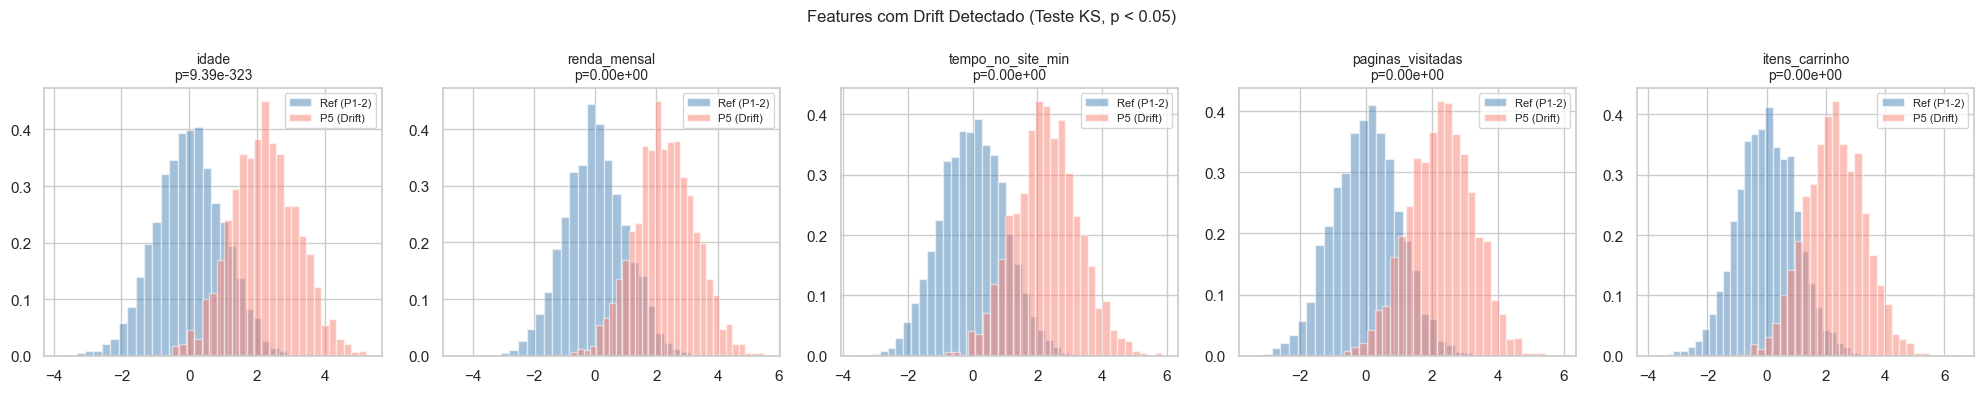

In [9]:
# Histogramas para as features com drift detectado
drifted = [r for r in results_p5 if r.drift_detected]

n_plots = min(len(drifted), 5)
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
if n_plots == 1:
    axes = [axes]

for ax, r in zip(axes, drifted[:5]):
    idx = feature_names.index(r.feature_name)
    ax.hist(X_ref[:, idx], bins=30, alpha=0.5, label="Ref (P1-2)", density=True, color="steelblue")
    ax.hist(X_p5[:, idx], bins=30, alpha=0.5, label="P5 (Drift)", density=True, color="salmon")
    ax.set_title(f"{r.feature_name}\np={r.p_value:.2e}", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Features com Drift Detectado (Teste KS, p < 0.05)", fontsize=12)
plt.tight_layout()
fig.savefig(Path.cwd().parent / "outputs" / "figures" / "drift_ks_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Salvar Métricas e Resultados

In [10]:
# Salva métricas por período
metrics_path = Path.cwd().parent / "outputs" / "logs" / "metrics_per_period.json"
save_metrics(
    {"metrics_by_period": {str(k): v for k, v in metrics_by_period.items()}},
    metrics_path,
)
print(f"Métricas salvas em {metrics_path}")

Métricas salvas em c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\01_fundamentos_do_data_drift_em_ml\outputs\logs\metrics_per_period.json


## Resumo

Neste notebook:
1. **Treinamos** um classificador (SGDClassifier) nos dados de referência
2. **Observamos a degradação** da acurácia conforme o drift aumenta
3. **Detectamos drift** estatisticamente com o teste KS em cada feature
4. **Confirmamos** que as features com deslocamento de média são identificadas

Isso valida o conceito de que monitorar P(X) é essencial para detectar
data drift antes que a performance degrade significativamente.

**Próximo:** [03_avaliacao.ipynb](03_avaliacao.ipynb) — Aprendizado incremental
e estratégias de resposta ao drift.